In [1]:
import sys
print(sys.executable)

/opt/anaconda3/envs/dedalus3/bin/python


In [11]:
import os
os.environ['OMP_NUM_THREADS'] = '1'      # must be set before numpy is imported
os.environ['NUMEXPR_MAX_THREADS'] = '1'

import sys
import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3

from mpi4py import MPI
import time

import logging
logging.disable(logging.INFO)   # hide INFO messages (Dedalus's "Building subproblem matrices..." lines)

from scipy.optimize import brentq, minimize_scalar

%matplotlib inline
print(sys.executable)

/opt/anaconda3/envs/dedalus3/bin/python


In [5]:
# CREDIT: adapted from the Dedalus examples repository (evp_1d_rayleigh_benard)

def max_growth_rate(Rayleigh, Prandtl, kx, Nz, NEV=10, target=0):
    """Largest linear growth rate, Im(omega), of no-slip Rayleigh-Benard
    convection at one horizontal wavenumber kx (nondimensionalised with
    the box height and free-fall time)."""

    # Parameters
    Lz = 1
    # Build Fourier basis for x with prescribed kx as the fundamental mode
    Nx = 2
    Lx = 2 * np.pi / kx

    # Bases
    coords = d3.CartesianCoordinates('x', 'z')
    dist = d3.Distributor(coords, dtype=np.complex128, comm=MPI.COMM_SELF)
    xbasis = d3.ComplexFourier(coords['x'], size=Nx, bounds=(0, Lx))
    zbasis = d3.ChebyshevT(coords['z'], size=Nz, bounds=(0, Lz))

    # Fields
    omega = dist.Field(name='omega')
    p = dist.Field(name='p', bases=(xbasis,zbasis))
    b = dist.Field(name='b', bases=(xbasis,zbasis))
    u = dist.VectorField(coords, name='u', bases=(xbasis,zbasis))
    tau_p = dist.Field(name='tau_p')
    tau_b1 = dist.Field(name='tau_b1', bases=xbasis)
    tau_b2 = dist.Field(name='tau_b2', bases=xbasis)
    tau_u1 = dist.VectorField(coords, name='tau_u1', bases=xbasis)
    tau_u2 = dist.VectorField(coords, name='tau_u2', bases=xbasis)

    # Substitutions
    kappa = (Rayleigh * Prandtl)**(-1/2)
    nu = (Rayleigh / Prandtl)**(-1/2)
    x, z = dist.local_grids(xbasis, zbasis)
    ex, ez = coords.unit_vector_fields(dist)
    lift_basis = zbasis.derivative_basis(1)
    lift = lambda A: d3.Lift(A, lift_basis, -1)
    grad_u = d3.grad(u) + ez*lift(tau_u1) # First-order reduction
    grad_b = d3.grad(b) + ez*lift(tau_b1) # First-order reduction
    dt = lambda A: -1j*omega*A

    # Problem
    problem = d3.EVP([p, b, u, tau_p, tau_b1, tau_b2, tau_u1, tau_u2], namespace=locals(), eigenvalue=omega)
    problem.add_equation("trace(grad_u) + tau_p = 0")
    problem.add_equation("dt(b) - kappa*div(grad_b) + lift(tau_b2) - ez@u = 0")
    problem.add_equation("dt(u) - nu*div(grad_u) + grad(p) - b*ez + lift(tau_u2) = 0")
    problem.add_equation("b(z=0) = 0")
    problem.add_equation("u(z=0) = 0")
    problem.add_equation("b(z=Lz) = 0")
    problem.add_equation("u(z=Lz) = 0")
    problem.add_equation("integ(p) = 0") # Pressure gauge

    # Solver
    solver = problem.build_solver(entry_cutoff=0)
    solver.solve_sparse(solver.subproblems[1], NEV, target=target)
    return np.max(solver.eigenvalues.imag)


def growth_over_kx_range(Rayleigh, Prandtl, kx_values, Nz, NEV=10, target=0):
    """Largest growth rate at each wavenumber in kx_values, for one Rayleigh
    number. Returns an array the same length as kx_values."""
    return np.array([max_growth_rate(Rayleigh, Prandtl, kx, Nz, NEV=NEV, target=target)
                     for kx in kx_values])

Solve time: 6.2 s
Max growth rate = 4.119e-04 at kx = 3.1173


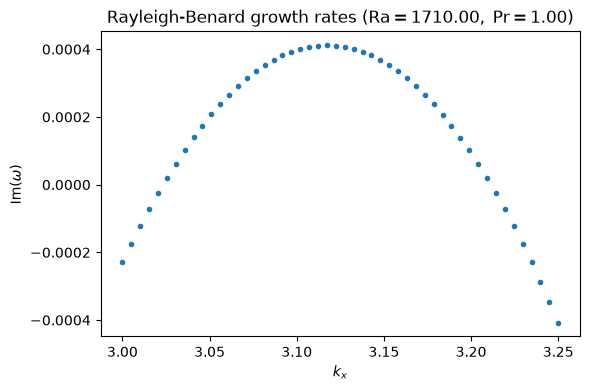

In [10]:
Ra = 1710
Prandtl = 1
Nz = 64
kx_values = np.linspace(3.0, 3.25, 50)

t0 = time.time()
growth = growth_over_kx_range(Ra, Prandtl, kx_values, Nz)
print(f'Solve time: {time.time() - t0:.1f} s')
print(f'Max growth rate = {growth.max():.3e} at kx = {kx_values[growth.argmax()]:.4f}')

plt.figure(figsize=(6, 4))
plt.plot(kx_values, growth, '.')
plt.xlabel(r'$k_x$')
plt.ylabel(r'$\mathrm{Im}(\omega)$')
plt.title(r'Rayleigh-Benard growth rates ($\mathrm{Ra} = %.2f, \; \mathrm{Pr} = %.2f$)' % (Ra, Prandtl))
plt.tight_layout()
plt.savefig('growth_rates_vs_kx.pdf')
plt.show()

In [14]:
def peak_growth(Rayleigh, Prandtl, kx_bounds, Nz, NEV=10, kx_tol=1e-3):
    """Maximise the growth rate over kx (continuously, not just on a grid).
    Returns (max growth rate, kx at the maximum).""" 
    res = minimize_scalar(lambda kx: -max_growth_rate(Rayleigh, Prandtl, kx, Nz, NEV=NEV),
                          bounds=kx_bounds, method='bounded', options={'xatol': kx_tol})
    return -res.fun, res.x

In [15]:
Prandtl = 1
Nz = 64
NEV = 10
kx_range = np.linspace(2.0, 4.5, 30)
Ra_range = np.linspace(1000, 2500, 16)

t0 = time.time()
growth_2d = np.zeros((len(Ra_range), len(kx_range)))
for i, Ra in enumerate(Ra_range):
    growth_2d[i, :] = growth_over_kx_range(Ra, Prandtl, kx_range, Nz, NEV=NEV)
    print(f'Finished Ra = {Ra:.1f} ({i+1}/{len(Ra_range)})')
print(f'Scan took {time.time() - t0:.0f} s')
np.savez('growth_2d.npz', Ra_range=Ra_range, kx_range=kx_range, growth_2d=growth_2d)

# To reload later without rerunning the scan, use:
# data = np.load('growth_2d.npz')
# Ra_range, kx_range, growth_2d = data['Ra_range'], data['kx_range'], data['growth_2d']

Finished Ra = 1000.0 (1/16)
Finished Ra = 1100.0 (2/16)
Finished Ra = 1200.0 (3/16)
Finished Ra = 1300.0 (4/16)
Finished Ra = 1400.0 (5/16)
Finished Ra = 1500.0 (6/16)
Finished Ra = 1600.0 (7/16)
Finished Ra = 1700.0 (8/16)
Finished Ra = 1800.0 (9/16)
Finished Ra = 1900.0 (10/16)
Finished Ra = 2000.0 (11/16)
Finished Ra = 2100.0 (12/16)
Finished Ra = 2200.0 (13/16)
Finished Ra = 2300.0 (14/16)
Finished Ra = 2400.0 (15/16)
Finished Ra = 2500.0 (16/16)
Scan took 65 s


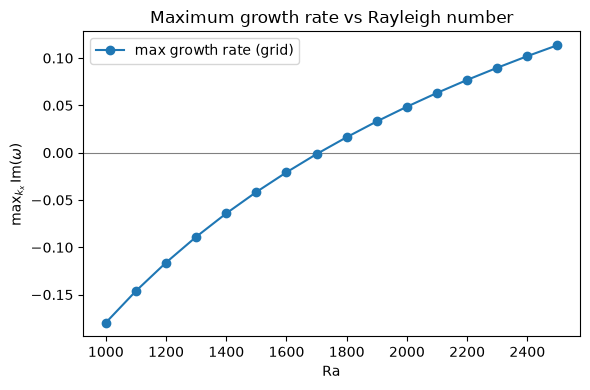

In [16]:
max_growth_vs_Ra = growth_2d.max(axis=1)

plt.figure(figsize=(6, 4))
plt.axhline(0, color='gray', lw=0.8)
plt.plot(Ra_range, max_growth_vs_Ra, 'o-', label='max growth rate (grid)')
plt.xlabel(r'$\mathrm{Ra}$')
plt.ylabel(r'max$_{k_x}\,\mathrm{Im}(\omega)$')
plt.title('Maximum growth rate vs Rayleigh number')
plt.legend()
plt.tight_layout()
plt.savefig('max_growth_vs_Ra_grid.pdf')
plt.show()

In [17]:
# Bracket the root: first pair of neighbouring Ra values where the max growth rate changes sign
sign_changes = np.where(np.diff(np.sign(max_growth_vs_Ra)))[0]
if len(sign_changes) == 0:
    raise ValueError('No sign change in max growth rate: widen Ra_range.')
i0 = sign_changes[0]
Ra_bracket = (Ra_range[i0], Ra_range[i0 + 1])
kx_bounds = (kx_range[0], kx_range[-1])
Ra_tol = 1e-2
kx_tol = 1e-3

# Refine with Brent's method, optimising over kx at each trial Ra
Ra_crit = brentq(lambda Ra: peak_growth(Ra, Prandtl, kx_bounds, Nz, NEV, kx_tol)[0],
                 *Ra_bracket, xtol=Ra_tol)
kx_crit = peak_growth(Ra_crit, Prandtl, kx_bounds, Nz, NEV, kx_tol)[1]

print(f'Numerical Ra_c = {Ra_crit:.4f}, kx_c = {kx_crit:.4f}')
print('Analytical:      Ra_c = 1707.76, kx_c = 3.117')

Numerical Ra_c = 1707.7625, kx_c = 3.1164
Analytical:      Ra_c = 1707.76, kx_c = 3.117


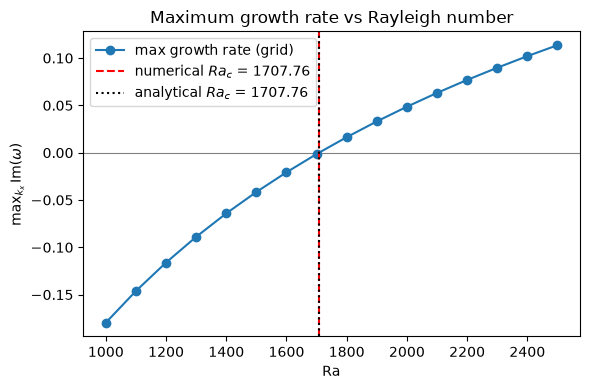

In [18]:
plt.figure(figsize=(6, 4))
plt.axhline(0, color='gray', lw=0.8)
plt.plot(Ra_range, max_growth_vs_Ra, 'o-', label='max growth rate (grid)')
plt.axvline(Ra_crit, color='red', ls='--', label=r'numerical $Ra_c$ = %.2f' % Ra_crit)
plt.axvline(1707.76, color='black', ls=':', label=r'analytical $Ra_c$ = 1707.76')
plt.xlabel(r'$\mathrm{Ra}$')
plt.ylabel(r'max$_{k_x}\,\mathrm{Im}(\omega)$')
plt.title('Maximum growth rate vs Rayleigh number')
plt.legend()
plt.tight_layout()
plt.savefig('max_growth_vs_Ra.pdf')
plt.show()

8 neutral-curve points found


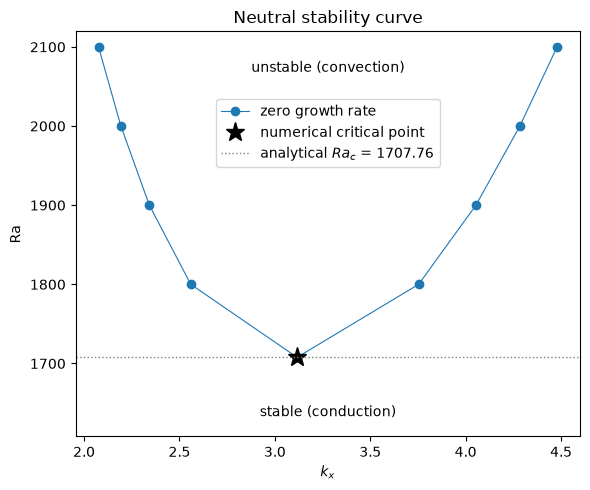

In [22]:
# Zero crossings along kx for each Ra, by linear interpolation between grid points
kx_pts, Ra_pts = [], []
for Ra, row in zip(Ra_range, growth_2d):
    s = np.sign(row)
    for i in np.where(s[:-1] * s[1:] < 0)[0]:    # sign change between grid points i and i+1
        kx_cross = kx_range[i] - row[i] * (kx_range[i+1] - kx_range[i]) / (row[i+1] - row[i])
        kx_pts.append(kx_cross)
        Ra_pts.append(Ra)
print(f'{len(kx_pts)} neutral-curve points found')

# Add the critical point as the bottom of the curve, then sort by kx
kx_all = np.append(kx_pts, kx_crit)
Ra_all = np.append(Ra_pts, Ra_crit)
order = np.argsort(kx_all)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(kx_all[order], Ra_all[order], 'o-', lw=0.8, label='zero growth rate')
ax.plot(kx_crit, Ra_crit, 'k*', markersize=14, label='numerical critical point')
ax.axhline(1707.76, color='gray', ls=':', lw=1, label=r'analytical $Ra_c$ = 1707.76')
ax.text(0.5, 0.9, 'unstable (convection)', transform=ax.transAxes, ha='center')
ax.text(0.5, 0.05, 'stable (conduction)', transform=ax.transAxes, ha='center')
ax.set_ylim(bottom=Ra_crit - 100)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$\mathrm{Ra}$')
ax.set_title('Neutral stability curve')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 0.85))
fig.tight_layout()
fig.savefig('neutral_curve.pdf')
plt.show()

In [23]:
import os, shutil, pathlib
import h5py

In [24]:
# CREDIT: adapted from the Dedalus examples repository (ivp_2d_rayleigh_benard)

def run_rayleigh_benard(Rayleigh, stop_sim_time, Nx=256, Nz=64, Prandtl=1, Lx=4, Lz=1,
                        outdir=None, overwrite=False, snapshot_dt=0.25, max_timestep=0.125):
    """Run 2D horizontally periodic Rayleigh-Benard convection (no-slip, fixed
    temperature) and save buoyancy snapshots to a folder of HDF5 files.

    Nondimensionalised with the box height and free-fall time:
        kappa = (Rayleigh*Prandtl)**(-1/2),  nu = (Rayleigh/Prandtl)**(-1/2).
    The folder is named after Ra (e.g. snapshots_Ra2e06) unless outdir is given.
    If the folder already exists the run is skipped, unless overwrite=True.
    Returns the folder name."""

    if outdir is None:
        outdir = f'snapshots_Ra{Rayleigh:.0e}'.replace('+', '')
    if os.path.exists(outdir):
        if overwrite:
            shutil.rmtree(outdir)
        else:
            print(f'{outdir} already exists: skipping (use overwrite=True to rerun)')
            return outdir

    dealias = 3/2
    timestepper = d3.RK222
    dtype = np.float64

    # Bases
    coords = d3.CartesianCoordinates('x', 'z')
    dist = d3.Distributor(coords, dtype=dtype)
    xbasis = d3.RealFourier(coords['x'], size=Nx, bounds=(0, Lx), dealias=dealias)
    zbasis = d3.ChebyshevT(coords['z'], size=Nz, bounds=(0, Lz), dealias=dealias)

    # Fields
    p = dist.Field(name='p', bases=(xbasis,zbasis))
    b = dist.Field(name='b', bases=(xbasis,zbasis))
    u = dist.VectorField(coords, name='u', bases=(xbasis,zbasis))
    tau_p = dist.Field(name='tau_p')
    tau_b1 = dist.Field(name='tau_b1', bases=xbasis)
    tau_b2 = dist.Field(name='tau_b2', bases=xbasis)
    tau_u1 = dist.VectorField(coords, name='tau_u1', bases=xbasis)
    tau_u2 = dist.VectorField(coords, name='tau_u2', bases=xbasis)

    # Substitutions
    kappa = (Rayleigh * Prandtl)**(-1/2)
    nu = (Rayleigh / Prandtl)**(-1/2)
    x, z = dist.local_grids(xbasis, zbasis)
    ex, ez = coords.unit_vector_fields(dist)
    lift_basis = zbasis.derivative_basis(1)
    lift = lambda A: d3.Lift(A, lift_basis, -1)
    grad_u = d3.grad(u) + ez*lift(tau_u1) # First-order reduction
    grad_b = d3.grad(b) + ez*lift(tau_b1) # First-order reduction

    # Problem
    problem = d3.IVP([p, b, u, tau_p, tau_b1, tau_b2, tau_u1, tau_u2], namespace=locals())
    problem.add_equation("trace(grad_u) + tau_p = 0")
    problem.add_equation("dt(b) - kappa*div(grad_b) + lift(tau_b2) = - u@grad(b)")
    problem.add_equation("dt(u) - nu*div(grad_u) + grad(p) - b*ez + lift(tau_u2) = - u@grad(u)")
    problem.add_equation("b(z=0) = Lz")
    problem.add_equation("u(z=0) = 0")
    problem.add_equation("b(z=Lz) = 0")
    problem.add_equation("u(z=Lz) = 0")
    problem.add_equation("integ(p) = 0") # Pressure gauge

    # Solver
    solver = problem.build_solver(timestepper)
    solver.stop_sim_time = stop_sim_time

    # Initial conditions
    b.fill_random('g', seed=42, distribution='normal', scale=1e-3) # Random noise
    b['g'] *= z * (Lz - z) # Damp noise at walls
    b['g'] += Lz - z # Add linear background

    # Analysis: buoyancy only
    snapshots = solver.evaluator.add_file_handler(outdir, sim_dt=snapshot_dt, max_writes=50)
    snapshots.add_task(b, name='buoyancy')

    # CFL
    CFL = d3.CFL(solver, initial_dt=max_timestep, cadence=10, safety=0.5, threshold=0.05,
                 max_change=1.5, min_change=0.5, max_dt=max_timestep)
    CFL.add_velocity(u)

    # Main loop
    t0 = time.time()
    while solver.proceed:
        timestep = CFL.compute_timestep()
        solver.step(timestep)
        if solver.iteration % 200 == 0:
            print(f'  Ra = {Rayleigh:.0e}:  t = {solver.sim_time:.1f} / {stop_sim_time},  dt = {timestep:.4f}')
    print(f'Ra = {Rayleigh:.0e} finished in {time.time() - t0:.0f} s -> {outdir}')
    return outdir


def load_task(folder, task='buoyancy'):
    """Read one saved task from every .h5 file in folder.
    Returns times, x, z, data, with data of shape (n_times, Nx, Nz), sorted by time."""
    times, chunks = [], []
    x = z = None
    for fname in sorted(pathlib.Path(folder).glob('*.h5')):
        with h5py.File(fname, mode='r') as f:
            dset = f['tasks'][task]
            if x is None:
                x = dset.dims[1][0][:]
                z = dset.dims[2][0][:]
            times.append(f['scales/sim_time'][:])
            chunks.append(dset[:])
    times = np.concatenate(times)
    data = np.concatenate(chunks)
    order = np.argsort(times)
    return times[order], x, z, data[order]

In [25]:
outdir = run_rayleigh_benard(2e6, stop_sim_time=50)

snapshots_Ra2e06 already exists: skipping (use overwrite=True to rerun)


200 snapshots, t = 0.00 to 49.75


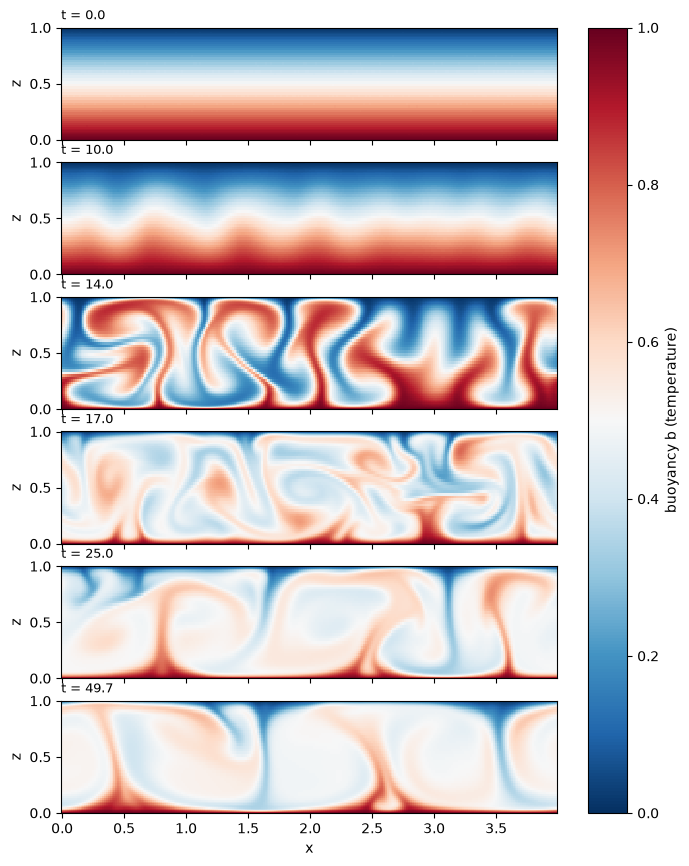

In [26]:
times, x, z, b = load_task(outdir, 'buoyancy')
print(f'{len(times)} snapshots, t = {times[0]:.2f} to {times[-1]:.2f}')

times_to_show = [0, 10, 14, 17, 25, 50]    # edit freely: each gives one panel
fig, axes = plt.subplots(len(times_to_show), 1, figsize=(8, 1.7*len(times_to_show)), sharex=True)
for ax, t_show in zip(axes, times_to_show):
    i = np.argmin(np.abs(times - t_show))      # snapshot nearest to the requested time
    im = ax.pcolormesh(x, z, b[i].T, cmap='RdBu_r', vmin=0, vmax=1, shading='nearest')
    ax.set_title(f't = {times[i]:.1f}', fontsize=9, loc='left')
    ax.set_ylabel('z')
axes[-1].set_xlabel('x')
fig.colorbar(im, ax=axes, label='buoyancy b (temperature)')
fig.savefig('snapshots.png', dpi=150, bbox_inches='tight')
plt.show()

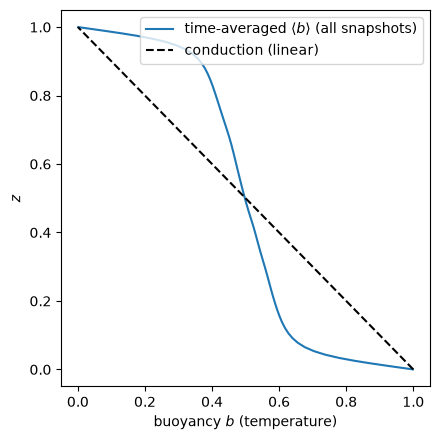

In [28]:
Lz = 1
bxm = b.mean(axis=1)                  # x-average of every snapshot -> (n_times, Nz)
b_mean_all = bxm.mean(axis=0)         # average over every snapshot, including the start-up

plt.figure(figsize=(4.5, 4.5))
plt.plot(b_mean_all, z, label=r'time-averaged $\langle b\rangle$ (all snapshots)')
plt.plot(Lz - z, z, 'k--', label='conduction (linear)')
plt.xlabel('buoyancy $b$ (temperature)')
plt.ylabel('$z$')
plt.legend()
plt.tight_layout()
plt.savefig('mean_profile_all_Ra2e06.pdf')
plt.show()

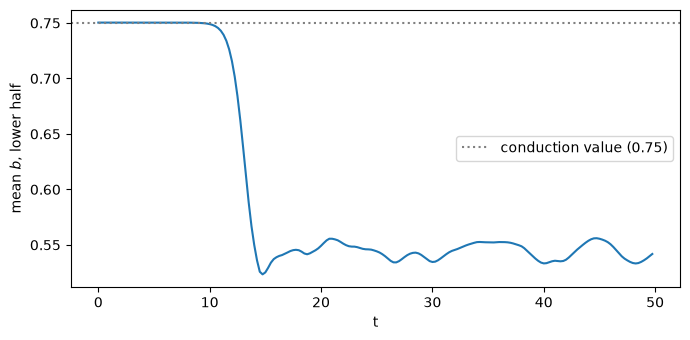

In [29]:
#Find out where convection kicks in, so we can discard the conduction-like results before that
w = np.gradient(z)                    # approximate layer thickness at each z point
low = z < 0.5
b_low = (bxm[:, low] * w[low]).sum(axis=1) / w[low].sum()

plt.figure(figsize=(7, 3.5))
plt.plot(times, b_low)
plt.axhline(0.75, color='gray', ls=':', label='conduction value (0.75)')
plt.xlabel('t')
plt.ylabel('mean $b$, lower half')
plt.legend()
plt.tight_layout()
plt.savefig('lower_half_mean_Ra2e06.pdf')
plt.show()

139 of 200 snapshots used, t = 15.25 to 49.75
Max deviation from conduction:  all snapshots 0.269,  after t = 15 0.360


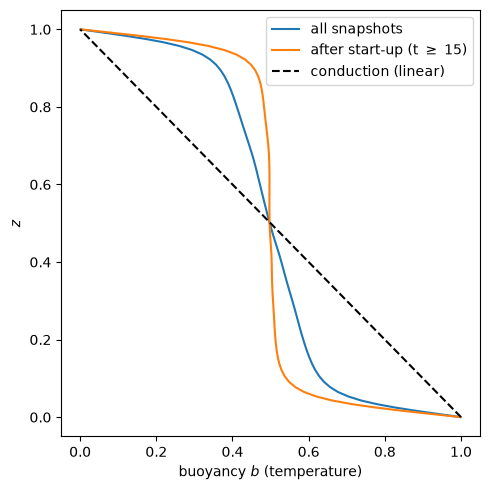

In [30]:
tstart = 15    # rom the plot above, this is where the dip has levelled off

keep = times >= tstart
b_mean_steady = bxm[keep].mean(axis=0)
print(f'{keep.sum()} of {len(times)} snapshots used, t = {times[keep][0]:.2f} to {times[keep][-1]:.2f}')
print(f'Max deviation from conduction:  all snapshots {np.abs(b_mean_all - (Lz - z)).max():.3f},  '
      f'after t = {tstart} {np.abs(b_mean_steady - (Lz - z)).max():.3f}')

plt.figure(figsize=(5, 5))
plt.plot(b_mean_all, z, label='all snapshots')
plt.plot(b_mean_steady, z, label=f'after start-up (t $\\geq$ {tstart})')
plt.plot(Lz - z, z, 'k--', label='conduction (linear)')
plt.xlabel('buoyancy $b$ (temperature)')
plt.ylabel('$z$')
plt.legend()
plt.tight_layout()
plt.savefig('mean_profile_comparison_Ra2e06.pdf')
plt.show()

In [ ]:
#Now need to loop over lots of Ra and extract the temp profiles from them. 
#Will choose 1e4, 1e and 1e6.

In [47]:
# Rayleigh numbers and how long to run each: the stop times are guesses, check them in the settling plot
runs = {2e3:200, 1e4: 100, 1e5: 75, 2e6: 50}

folders = {}
for Ra, t_stop in runs.items():
    folders[Ra] = run_rayleigh_benard(Ra, stop_sim_time=t_stop)

  Ra = 2e+03:  t = 25.0 / 200,  dt = 0.1250
  Ra = 2e+03:  t = 50.0 / 200,  dt = 0.1250
  Ra = 2e+03:  t = 75.0 / 200,  dt = 0.1250
  Ra = 2e+03:  t = 100.0 / 200,  dt = 0.1250
  Ra = 2e+03:  t = 125.0 / 200,  dt = 0.1250
  Ra = 2e+03:  t = 150.0 / 200,  dt = 0.1250
  Ra = 2e+03:  t = 175.0 / 200,  dt = 0.1250
  Ra = 2e+03:  t = 200.0 / 200,  dt = 0.1250
Ra = 2e+03 finished in 88 s -> snapshots_Ra2e03
  Ra = 1e+04:  t = 25.0 / 100,  dt = 0.1250
  Ra = 1e+04:  t = 33.3 / 100,  dt = 0.0234
  Ra = 1e+04:  t = 38.6 / 100,  dt = 0.0279
  Ra = 1e+04:  t = 44.2 / 100,  dt = 0.0279
  Ra = 1e+04:  t = 49.8 / 100,  dt = 0.0279
  Ra = 1e+04:  t = 55.3 / 100,  dt = 0.0279
  Ra = 1e+04:  t = 60.9 / 100,  dt = 0.0279
  Ra = 1e+04:  t = 66.5 / 100,  dt = 0.0279
  Ra = 1e+04:  t = 72.1 / 100,  dt = 0.0279
  Ra = 1e+04:  t = 77.7 / 100,  dt = 0.0279
  Ra = 1e+04:  t = 83.3 / 100,  dt = 0.0279
  Ra = 1e+04:  t = 88.9 / 100,  dt = 0.0279
  Ra = 1e+04:  t = 94.4 / 100,  dt = 0.0279
Ra = 1e+04 finished in 

In [48]:
#load all the runs and x-average them
Lz = 1
data = {}
for Ra, folder in folders.items():
    t, x, z, b = load_task(folder, 'buoyancy')
    data[Ra] = dict(t=t, z=z, bxm=b.mean(axis=1))      # bxm: x-average, shape (n_times, Nz)
    print(f'Ra = {Ra:.0e}: {len(t)} snapshots, t = {t[0]:.1f} to {t[-1]:.1f}')

Ra = 2e+03: 800 snapshots, t = 0.0 to 199.8
Ra = 1e+04: 401 snapshots, t = 0.0 to 100.0
Ra = 1e+05: 301 snapshots, t = 0.0 to 75.0
Ra = 2e+06: 200 snapshots, t = 0.0 to 49.7


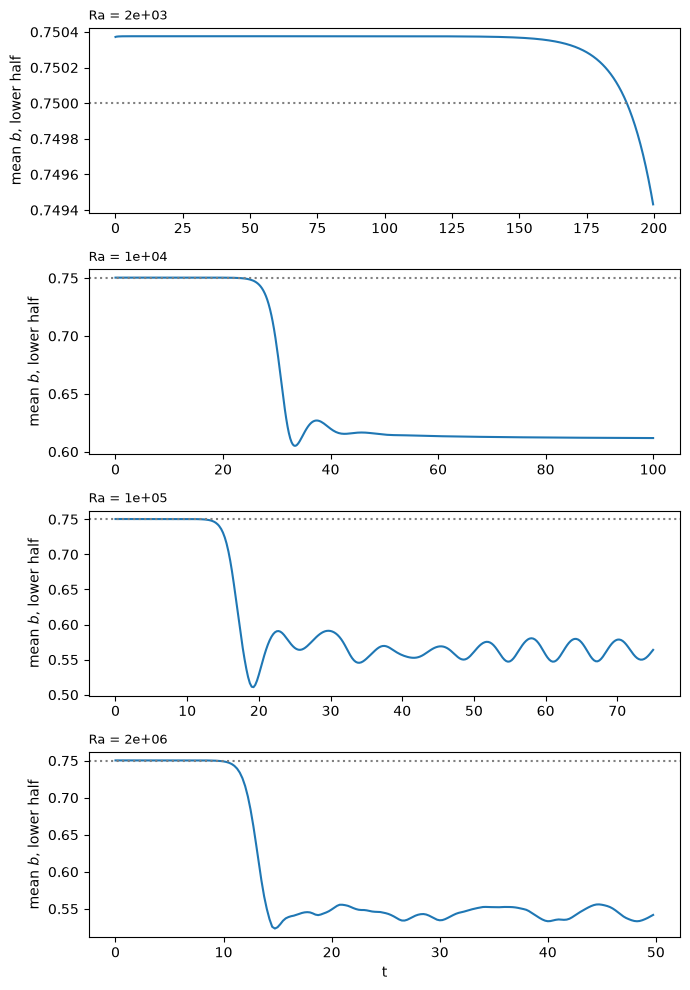

In [49]:
#settling check for every run (one panel each)
fig, axes = plt.subplots(len(data), 1, figsize=(7, 2.5*len(data)))
for ax, (Ra, d) in zip(axes, data.items()):
    w = np.gradient(d['z'])
    low = d['z'] < 0.5
    b_low = (d['bxm'][:, low] * w[low]).sum(axis=1) / w[low].sum()
    ax.plot(d['t'], b_low)
    ax.axhline(0.75, color='gray', ls=':')
    ax.set_title(f'Ra = {Ra:.0e}', loc='left', fontsize=9)
    ax.set_ylabel('mean $b$, lower half')
axes[-1].set_xlabel('t')
fig.tight_layout()
plt.show()

In [ ]:
#convection barely took hold in the 2e3 place. I will delete this run and redo at 5e3:

In [51]:
del folders[2e3]
print(folders)

{10000.0: 'snapshots_Ra1e04', 100000.0: 'snapshots_Ra1e05', 2000000.0: 'snapshots_Ra2e06'}


In [56]:
#and need to delete the data entries:
data.pop(2e3, None)       # remove Ra = 2000 from the loaded data (does nothing if it's already gone)

{'t': array([  0.  ,   0.25,   0.5 ,   0.75,   1.  ,   1.25,   1.5 ,   1.75,
          2.  ,   2.25,   2.5 ,   2.75,   3.  ,   3.25,   3.5 ,   3.75,
          4.  ,   4.25,   4.5 ,   4.75,   5.  ,   5.25,   5.5 ,   5.75,
          6.  ,   6.25,   6.5 ,   6.75,   7.  ,   7.25,   7.5 ,   7.75,
          8.  ,   8.25,   8.5 ,   8.75,   9.  ,   9.25,   9.5 ,   9.75,
         10.  ,  10.25,  10.5 ,  10.75,  11.  ,  11.25,  11.5 ,  11.75,
         12.  ,  12.25,  12.5 ,  12.75,  13.  ,  13.25,  13.5 ,  13.75,
         14.  ,  14.25,  14.5 ,  14.75,  15.  ,  15.25,  15.5 ,  15.75,
         16.  ,  16.25,  16.5 ,  16.75,  17.  ,  17.25,  17.5 ,  17.75,
         18.  ,  18.25,  18.5 ,  18.75,  19.  ,  19.25,  19.5 ,  19.75,
         20.  ,  20.25,  20.5 ,  20.75,  21.  ,  21.25,  21.5 ,  21.75,
         22.  ,  22.25,  22.5 ,  22.75,  23.  ,  23.25,  23.5 ,  23.75,
         24.  ,  24.25,  24.5 ,  24.75,  25.  ,  25.25,  25.5 ,  25.75,
         26.  ,  26.25,  26.5 ,  26.75,  27.  ,  27.25,  27

In [52]:
folders[5e3] = run_rayleigh_benard(5e3, stop_sim_time=200)

  Ra = 5e+03:  t = 25.0 / 200,  dt = 0.1250
  Ra = 5e+03:  t = 44.4 / 200,  dt = 0.0364
  Ra = 5e+03:  t = 50.3 / 200,  dt = 0.0282
  Ra = 5e+03:  t = 56.0 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 61.9 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 67.8 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 73.8 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 79.7 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 85.6 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 91.5 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 97.4 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 103.3 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 109.3 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 115.2 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 121.1 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 127.0 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 132.9 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 138.8 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 144.8 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 150.7 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 156.6 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 162.5 / 200,  dt = 0.0296
  Ra = 5e+03:  t = 16

Ra = 5e+03: 801 snapshots, t = 0.0 to 200.0


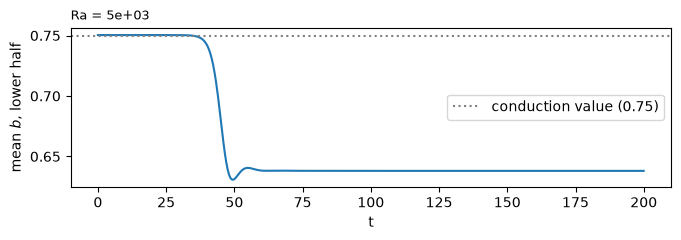

In [53]:
#now plot the settling plot for just 5e3 to see when convection settled: 
Ra_new = 5e3
t_new, x_new, z_new, b_new = load_task(folders[Ra_new], 'buoyancy')
data[Ra_new] = dict(t=t_new, z=z_new, bxm=b_new.mean(axis=1))
print(f'Ra = {Ra_new:.0e}: {len(t_new)} snapshots, t = {t_new[0]:.1f} to {t_new[-1]:.1f}')

d = data[Ra_new]
w = np.gradient(d['z'])
low = d['z'] < 0.5
b_low = (d['bxm'][:, low] * w[low]).sum(axis=1) / w[low].sum()

plt.figure(figsize=(7, 2.5))
plt.plot(d['t'], b_low)
plt.axhline(0.75, color='gray', ls=':', label='conduction value (0.75)')
plt.title(f'Ra = {Ra_new:.0e}', loc='left', fontsize=9)
plt.xlabel('t')
plt.ylabel('mean $b$, lower half')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#definitely settled in time (by around 60), so can use this

In [54]:
#check folder contents:
print(folders)

{10000.0: 'snapshots_Ra1e04', 100000.0: 'snapshots_Ra1e05', 2000000.0: 'snapshots_Ra2e06', 5000.0: 'snapshots_Ra5e03'}


Ra = 5e+03: 561 snapshots used (t >= 60)
Ra = 1e+04: 241 snapshots used (t >= 40)
Ra = 1e+05: 201 snapshots used (t >= 25)
Ra = 2e+06: 139 snapshots used (t >= 15)


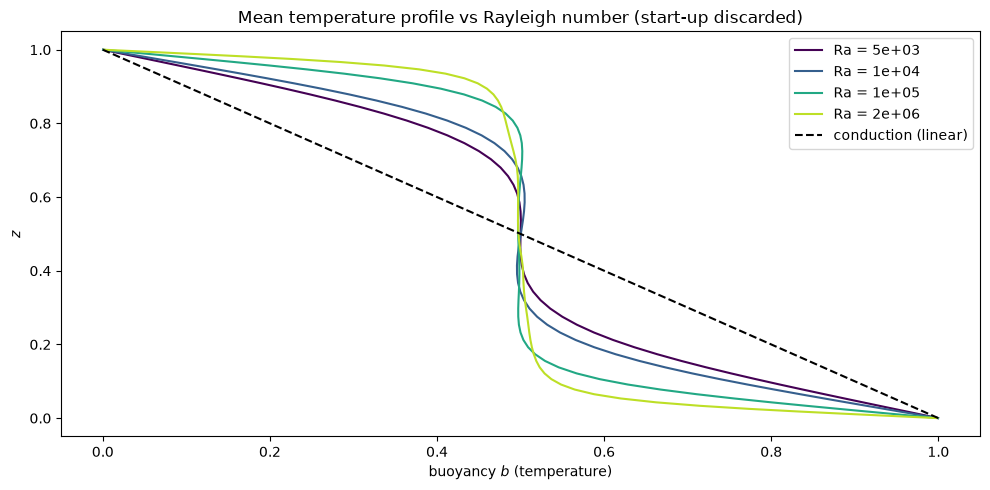

In [58]:
# Setting each start-up cutoff, using the panels above, after the dip has levelled off.
tstart = {5e3:60, 1e4: 40, 1e5: 25, 2e6: 15}

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(data)))
for (Ra, d), color in zip(sorted(data.items()), colors):
    keep = d['t'] >= tstart[Ra]
    if keep.sum() == 0:
        raise ValueError(f'No snapshots after tstart = {tstart[Ra]} for Ra = {Ra:.0e}')
    b_mean = d['bxm'][keep].mean(axis=0)
    ax.plot(b_mean, d['z'], color=color, label=f'Ra = {Ra:.0e}')
    print(f'Ra = {Ra:.0e}: {keep.sum()} snapshots used (t >= {tstart[Ra]})')

ax.plot(Lz - d['z'], d['z'], 'k--', label='conduction (linear)')
ax.set_xlabel('buoyancy $b$ (temperature)')
ax.set_ylabel('$z$')
ax.set_title('Mean temperature profile vs Rayleigh number (start-up discarded)')
ax.legend()
fig.tight_layout()
fig.savefig('mean_profiles_vs_Ra.pdf')
plt.show()

In [61]:
def wall_gradients(z, b_profile, Lz=1, edge_order=2):
    # append the known wall values (b=Lz at z=0, b=0 at z=Lz) to the grid
    z_ext = np.concatenate(([0], z, [Lz]))
    b_ext = np.concatenate(([Lz], b_profile, [0]))
    dbdz = np.gradient(b_ext, z_ext, edge_order=edge_order)   # handles non-uniform spacing
    return -dbdz[0], -dbdz[-1]      # Nu at bottom wall, Nu at top wall

In [60]:
print(f"{'Ra':>8} {'Nu_bot':>8} {'Nu_top':>8} {'Nu':>8} {'1st-order Nu':>13} {'delta':>7}")
Nu = {}
for Ra, d in sorted(data.items()):
    keep = d['t'] >= tstart[Ra]
    b_mean = d['bxm'][keep].mean(axis=0)
    nb, nt = wall_gradients(d['z'], b_mean)                  # 2nd-order one-sided difference
    nb1, nt1 = wall_gradients(d['z'], b_mean, edge_order=1)  # 1st-order, for comparison
    Nu[Ra] = 0.5 * (nb + nt)
    print(f"{Ra:8.0e} {nb:8.3f} {nt:8.3f} {Nu[Ra]:8.3f} {0.5*(nb1+nt1):13.3f} {1/(2*Nu[Ra]):7.3f}")

      Ra   Nu_bot   Nu_top       Nu  1st-order Nu   delta
   5e+03    2.112    2.112    2.112         2.112   0.237
   1e+04    2.574    2.576    2.575         2.575   0.194
   1e+05    4.767    4.752    4.760         4.760   0.105
   2e+06    9.493    9.465    9.479         9.479   0.053
